# TFG Pipeline
Adrià Rojo, 2026

## Compilar eines

In [1]:
# SDModel
! g++ -O3 -std=c++17 -lboost_system -lboost_math_c99 SD-model/src/generatingSD_unix.cpp -o tools/genSD
# Mercator
! g++ -O3 -std=c++11 -I mercator/include/ mercator/src/embeddingS1_unix.cpp -o tools/mercator
# Epidemics
! gfortran -O3 -march=native -funroll-loops \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main.f90 \
    -o ./tools/epidemics.out
! rm ./*.mod

In file included from /usr/include/boost/math/quadrature/gauss.hpp:15,
                 from SD-model/src/../include/generatingSD.hpp:40,
                 from SD-model/src/../include/generatingSD_unix.hpp:32,
                 from SD-model/src/generatingSD_unix.cpp:30:
/usr/include/boost/math/special_functions/legendre.hpp: In instantiation of 'std::pair<_FIter, _FIter> boost::math::detail::legendre_p_zero_func<T, Policy>::operator()(T) const [with T = double; Policy = boost::math::policies::policy<boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy>]':
/usr/include/boost/math/tools/roots.hpp:259:29:   required from

In [2]:
! ./tools/genSD -h


NAME
  generatingSD -- a program to generate complex networks in the S^D metric space

SYNOPSIS
  generatingSD [options]
  

The following options are available:
  -b [BETA]        Specifies the value for parameter beta.
  -d [DIMENSION]   Specifies model's dimension (S^D).
  -g [GAMMA]       Exponent of the power-law distribution for hidden degrees.
  -n [SIZE]        Network size.
  -k [MEAN_DEGREE] Mean degree of nodes.
  -l [KAPPAS]      File consisting of the hidden degrees 
  -s [SEED]        Program uses a custom seed for the random number generator. Default: EPOCH.
  -v               Outputs the hidden variables (kappa and nodes'positions) used to the generate the network into a file (uses the edgelist's rootname).
  -h               Print this message on screen and exit.
  -o [FILENAME]    Name of the output file (without extension) (default: net)
  


In [40]:
! ./tools/genSD -d 1 -n 3000 -g 3 -k 0.4 -b 4 -s 12345 -o pipeline-output/net

OUTPUT_ROOTNAME = /home/adria/universitat/tfg/pipeline-output/net
edgelist_file = /home/adria/universitat/tfg/pipeline-output/net.edge


In [4]:
! ./tools/mercator -h

./tools/mercator: invalid option -- 'h'

NAME
	Mercator: Inference of high-quality embeddings of complex networks into the
	          hyperbolic disk

SYNOPSIS
	mercator [options] <edgelist_filename>

INPUT
	The structure of the graph is provided by a text file containing it edgelist. Each
	line in the file corresponds to an edge in the graph (i.e., [VERTEX1] [VERTEX2]).
	  - The name of the vertices need not be integers (they are stored as std::string).
	  - Directed graphs will be converted to undirected.
	  - Multiple edges, self-loops and weights will be ignored.
	  - Lines starting with '# ' are ignored (i.e., comments).


The following options are available:
	-a             Screen mode. Program outputs details about its progress on screen
	               (through std::clog) instead of in a log file. Useful to gather all
	               output in a single file if mercator is a subroutine of a script.
	-b [VALUE]     Specify the value for beta to be used for the embedding. By 
	   

In [66]:
! ./tools/mercator -o pipeline-output/ -b 1.10 -g 1.738 -s 12345 ./epidemics-tfg/nets/inf-openflights.edges
! ./tools/mercator -o pipeline-output/ -b 1.10 -g 1.738 -s 12345 ./epidemics-tfg/nets/inf-openflights_GC.edge



More than one component found (2905/2939) vertices in the largest component.
Edges belonging to the largest component saved to ./epidemics-tfg/nets/inf-openflights_GC.edge. Please rerun the program using this new edgelist.

terminate called without an active exception


In [135]:
import numpy as np
import networkx as nx
import pandas as pd
def cart2pol(x, y):
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(rho, phi)

def pol2cart(kappa, phi, kmin, zeta):
    rho = (1/zeta) * np.log(kappa/kmin)  # o variantes
    r = np.tanh(rho / 2)  # Para visualización   
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return(x, y)

In [157]:
G = nx.read_edgelist("./epidemics-tfg/nets/inf-openflights_GC.edge")
pos = pd.read_csv("./pipeline-output/.inf_coord", sep='\\s+', comment='#', names=["Vertex", "Inf.Kappa", "Inf.Theta", "Inf.Hyp.Rad."])
min_kappa = max(pos['Inf.Kappa'])
positions_hyp = {str(v): (x, y) for v, x, y in zip(pos['Vertex'], pos['Inf.Kappa'], pos['Inf.Theta'])}
beta = 1
positions_cart = {str(v): pol2cart(x, y, min_kappa, beta) for v, (x, y) in positions_hyp.items()}
    
positions_hyp


{'1': (1.27932, 1.26403),
 '2': (45.276, 1.24781),
 '3': (5.45185, 1.23204),
 '4': (5.47838, 1.23211),
 '5': (4.67837, 1.23132),
 '6': (5.53971, 1.23006),
 '7': (8.35601, 1.23394),
 '8': (1.18065, 1.24822),
 '9': (2.74538, 1.24668),
 '10': (3.19858, 1.24337),
 '11': (6.56641, 1.2472),
 '12': (109.981, 1.92744),
 '13': (95.015, 2.1146),
 '14': (152.02, 1.76704),
 '15': (158.945, 1.96059),
 '16': (58.4018, 1.42589),
 '17': (25.0844, 1.42023),
 '18': (84.7475, 1.72041),
 '19': (33.4758, 1.30242),
 '20': (2.72919, 1.25393),
 '21': (1.85051, 1.22553),
 '22': (2.8157, 1.24849),
 '23': (1.62365, 1.26484),
 '24': (1.41778, 1.25937),
 '25': (4.62493, 1.24305),
 '26': (1.10307, 1.24836),
 '27': (3.39374, 1.24486),
 '28': (1.08376, 1.2596),
 '29': (1.06677, 1.25017),
 '30': (2.9268, 1.23857),
 '31': (1.41957, 1.258),
 '32': (2.5589, 1.25212),
 '33': (1.41247, 1.25937),
 '34': (4.23257, 2.45311),
 '35': (6.62025, 2.45444),
 '36': (5.77672, 2.45004),
 '37': (6.27822, 2.53984),
 '38': (1.37063, 2.45

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def lorentz_boost_to_center(nodos_dict, nodo_central, precision=1e-10):
    """
    Aplica una transformada de Lorentz para centrar un nodo específico en el origen.
    """
    # Obtener coordenadas del nodo a centrar
    r_c, theta_c = nodos_dict[nodo_central]
    
    # Convertir a coordenadas del hiperboloide
    x0_c = np.cosh(r_c)
    x1_c = np.sinh(r_c) * np.cos(theta_c)
    x2_c = np.sinh(r_c) * np.sin(theta_c)
    
    # Calcular los parámetros del boost
    norm = np.sqrt(x1_c**2 + x2_c**2)
    if norm > precision:
        u1 = x1_c / norm
        u2 = x2_c / norm
        gamma = x0_c
        beta = np.sqrt(1 - 1/gamma**2) if gamma >= 1 else 0
    else:
        return nodos_dict.copy()
    
    # Aplicar la transformación a todos los puntos
    nuevos_nodos = {}
    
    for nodo_id, (r, theta) in nodos_dict.items():
        # Convertir a coordenadas del hiperboloide
        x0 = np.cosh(r)
        x1 = np.sinh(r) * np.cos(theta)
        x2 = np.sinh(r) * np.sin(theta)
        
        # Calcular el producto escalar espacial
        x_dot_u = x1*u1 + x2*u2
        
        # Aplicar transformación de boost
        x0_nueva = gamma * x0 - gamma * beta * x_dot_u
        x1_nueva = x1 + (gamma - 1) * x_dot_u * u1 - gamma * beta * x0 * u1
        x2_nueva = x2 + (gamma - 1) * x_dot_u * u2 - gamma * beta * x0 * u2
        
        # Asegurar que x0_nueva sea >= 1
        x0_nueva = max(x0_nueva, 1.0)
        
        # Convertir de vuelta a coordenadas polares hiperbólicas
        r_nueva = np.arccosh(x0_nueva)
        
        # Calcular el ángulo
        if r_nueva > precision:
            # Calcular las coordenadas en el modelo de hiperboloide
            # y luego proyectar al disco de Poincaré directamente
            sinh_r = np.sinh(r_nueva)
            if sinh_r > 0:
                cos_theta = x1_nueva / sinh_r
                sin_theta = x2_nueva / sinh_r
                
                # Asegurar que los valores estén en el rango [-1, 1]
                cos_theta = np.clip(cos_theta, -1.0, 1.0)
                sin_theta = np.clip(sin_theta, -1.0, 1.0)
                
                theta_nueva = np.arctan2(sin_theta, cos_theta)
            else:
                theta_nueva = 0.0
        else:
            theta_nueva = 0.0
        
        nuevos_nodos[nodo_id] = (r_nueva, theta_nueva)
    
    return nuevos_nodos

def convertir_a_cartesianas(nodos_dict):
    """
    Convierte coordenadas polares hiperbólicas a cartesianas para visualización.
    
    Parámetros:
    -----------
    nodos_dict : dict
        Diccionario con formato {id_nodo: (r, theta)}
    
    Returns:
    --------
    dict : Diccionario con coordenadas cartesianas {id_nodo: (x, y)}
    """
    cartesianas = {}
    for nodo_id, (r, theta) in nodos_dict.items():
        # En el modelo de Poincaré, la transformación es: x = tanh(r/2) * cos(theta), y = tanh(r/2) * sin(theta)
        # Esto es para visualización en el disco de Poincaré
        r_poincare = np.tanh(r / 2)
        x = r_poincare * np.cos(theta)
        y = r_poincare * np.sin(theta)
        cartesianas[nodo_id] = (x, y)
    
    return cartesianas

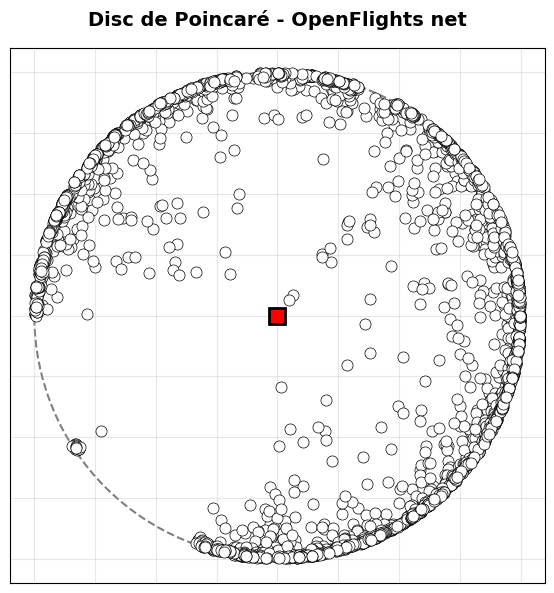

In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def visualizar_comparacion_corregida(cart_originales, 
                                     nodo_central, titulo="Comparación"):
    """
    Visualiza los nodos originales y transformados usando la proyección correcta.
    """
    # Convertir ambos usando la proyección correcta
    
    fig, ax1 = plt.subplots(1, 1, figsize=(14, 6))
    
    # Colores para identificar mejor los puntos
    
    # Grafo original
    for i, (x, y) in (cart_originales.items()):
        ax1.plot(x, y, 'o', color='white', markersize=8, markeredgecolor='black', markeredgewidth=0.5)
        # ax1.annotate(str(nodo_id), (x, y), xytext=(5, 5), 
        #             textcoords='offset points', fontsize=9, fontweight='bold')
    
    # Marcar el nodo que vamos a centrar
    x_cent_orig, y_cent_orig = cart_originales[nodo_central]
    ax1.plot(x_cent_orig, y_cent_orig, 's', color='red', markersize=12, 
             markeredgecolor='black', markeredgewidth=2, label=f'Nodo {nodo_central} (a centrar)')
    
    # Dibujar círculo unitario
    circle = plt.Circle((0, 0), 1, fill=False, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    ax1.add_patch(circle)
    ax1.set_xlim(-1.1, 1.1)
    ax1.set_ylim(-1.1, 1.1)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,
        left=False, 
        right=False,    # ticks along the top edge are off
        labelbottom=False,
        labelleft=False
    )
    plt.suptitle(titulo, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
ks = nx.degree(G)
max_k_node = max(dict(ks).items(), key=lambda x: x[1])
max_k_node_key = max_k_node[0]
# Visualizar con la nueva función
visualizar_comparacion_corregida(positions_cart, max_k_node_key,
                                f"Disc de Poincaré - OpenFlights net")